In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [2]:
RDKIT_DESCRIPTORS = [
    # Size & weight
    ('MolWt',               Descriptors.MolWt),
    ('HeavyAtomCount',      Descriptors.HeavyAtomCount),
    ('NumValenceElectrons', Descriptors.NumValenceElectrons),
    # Lipophilicity & polarity
    ('MolLogP',             Descriptors.MolLogP),
    ('MolMR',               Descriptors.MolMR),
    ('TPSA',                Descriptors.TPSA),
    ('LabuteASA',           Descriptors.LabuteASA),
    # H-bonding
    ('NumHDonors',          Descriptors.NumHDonors),
    ('NumHAcceptors',       Descriptors.NumHAcceptors),
    # Flexibility & shape
    ('NumRotatableBonds',   Descriptors.NumRotatableBonds),
    ('FractionCSP3',        Descriptors.FractionCSP3),
    ('BertzCT',             Descriptors.BertzCT),
    ('Ipc',                 Descriptors.Ipc),
    # Ring systems
    ('RingCount',           Descriptors.RingCount),
    ('NumAromaticRings',    Descriptors.NumAromaticRings),
    ('NumAliphaticRings',   Descriptors.NumAliphaticRings),
    ('NumSaturatedRings',   Descriptors.NumSaturatedRings),
    # Kappa shape indices
    ('Kappa1',              Descriptors.Kappa1),
    ('Kappa2',              Descriptors.Kappa2),
    ('Kappa3',              Descriptors.Kappa3),
    # Connectivity indices
    ('Chi0v',               Descriptors.Chi0v),
    ('Chi1v',               Descriptors.Chi1v),
    ('Chi2v',               Descriptors.Chi2v),
    ('Chi3v',               Descriptors.Chi3v),
    # EState
    ('MaxAbsEStateIndex',   Descriptors.MaxAbsEStateIndex),
    ('MinAbsEStateIndex',   Descriptors.MinAbsEStateIndex),
    # Charge-related VSA
    ('PEOE_VSA1',           Descriptors.PEOE_VSA1),
    ('PEOE_VSA2',           Descriptors.PEOE_VSA2),
    ('SlogP_VSA1',          Descriptors.SlogP_VSA1),
    ('SMR_VSA1',            Descriptors.SMR_VSA1),
]

def compute_rdkit_descriptors(mol):
    vals = []
    for _, fn in RDKIT_DESCRIPTORS:
        try:
            v = fn(mol)
            vals.append(float(v) if v is not None else 0.0)
        except:
            vals.append(0.0)
    return np.array(vals)

In [3]:
def smiles_to_features(df, smiles_col='mol', radius=2, nbits=2048):
    fps_morgan, fps_maccs, descriptors, valid_idx = [], [], [], []
    for i, row in df.iterrows():
        mol = Chem.MolFromSmiles(str(row[smiles_col]))
        if mol is None:
            continue
        morgan = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits))
        maccs  = np.array(MACCSkeys.GenMACCSKeys(mol))
        rdkit  = compute_rdkit_descriptors(mol)
        fps_morgan.append(morgan)
        fps_maccs.append(maccs)
        descriptors.append(rdkit)
        valid_idx.append(i)
    X = np.hstack([
        np.array(fps_morgan),   # 2048
        np.array(fps_maccs),    # 167
        np.array(descriptors)   # 30
    ])                          # total: 2245 features
    return X, valid_idx

print("Feature vector size: 2048 (Morgan) + 167 (MACCS) + 30 (RDKit) = 2245")

Feature vector size: 2048 (Morgan) + 167 (MACCS) + 30 (RDKit) = 2245


In [4]:
DATA_PATH = r"/Users/francisbateman/Desktop/Wadhams Start Up/Code/CL_VD_Data.xlsx"

cl_train = pd.read_excel(DATA_PATH, sheet_name='CL_imputated_training_dataset')
cl_eval  = pd.read_excel(DATA_PATH, sheet_name='CL_evaluation_dataset')
vd_train = pd.read_excel(DATA_PATH, sheet_name='VDss_imputated_training_dataset')
vd_eval  = pd.read_excel(DATA_PATH, sheet_name='VDss_evaluation_dataset')

X_cl_train, idx_cl_train = smiles_to_features(cl_train)
X_cl_eval,  idx_cl_eval  = smiles_to_features(cl_eval)
X_vd_train, idx_vd_train = smiles_to_features(vd_train)
X_vd_eval,  idx_vd_eval  = smiles_to_features(vd_eval)

y_cl_train = np.log(cl_train.loc[idx_cl_train, 'human_CL_mL_min_kg'].values)
y_cl_eval  = np.log(cl_eval.loc[idx_cl_eval,   'human_CL_mL_min_kg'].values)
y_vd_train = np.log(vd_train.loc[idx_vd_train, 'human_VDss_L_kg'].values)
y_vd_eval  = np.log(vd_eval.loc[idx_vd_eval,   'human_VDss_L_kg'].values)

print(f"CL train: {X_cl_train.shape}, eval: {X_cl_eval.shape}")
print(f"Vd train: {X_vd_train.shape}, eval: {X_vd_eval.shape}")

[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerator
[17:30:47] DEPRECATION WARNING: please use MorganGenerat

CL train: (695, 2245), eval: (46, 2245)
Vd train: (706, 2245), eval: (45, 2245)


In [5]:
def train_eval(X_train, y_train, X_eval, y_eval, label, model):
    model.fit(X_train, y_train)
    preds = model.predict(X_eval)
    r2   = r2_score(y_eval, preds)
    gmfe = 10 ** np.mean(np.abs(np.log10(np.exp(preds) / np.exp(y_eval))))
    print(f"{label}:  R²={r2:.3f}  GMFE={gmfe:.2f}")
    return model, preds

xgb_cl, cl_preds = train_eval(
    X_cl_train, y_cl_train, X_cl_eval, y_cl_eval, "CL  (XGBoost)",
    XGBRegressor(n_estimators=1022, learning_rate=0.07, max_depth=10,
                 subsample=0.782, colsample_bytree=0.699, min_child_weight=3,
                 gamma=1.804, reg_alpha=0.994, reg_lambda=0.223,
                 random_state=42, verbosity=0, n_jobs=-1)
)

rf_vd, vd_preds = train_eval(
    X_vd_train, y_vd_train, X_vd_eval, y_vd_eval, "Vd  (RF)",
    RandomForestRegressor(n_estimators=500, max_features='sqrt',
                          min_samples_leaf=2, random_state=42, n_jobs=-1)
)

CL  (XGBoost):  R²=0.393  GMFE=2.14
Vd  (RF):  R²=0.728  GMFE=1.69


In [6]:
CHEMBL_PATH = r"/Users/francisbateman/Desktop/Wadhams Start Up/Code/ChEMBL_new_CL_compounds.xlsx"
chembl = pd.read_excel(CHEMBL_PATH, sheet_name='New_CL_Compounds')
chembl = chembl.rename(columns={'SMILES': 'mol'})

X_chembl, idx_chembl = smiles_to_features(chembl)
y_chembl = np.log(chembl.loc[idx_chembl, 'human_CL_mL_min_kg'].values)

preds_ext = xgb_cl.predict(X_chembl)
r2_ext   = r2_score(y_chembl, preds_ext)
gmfe_ext = 10 ** np.mean(np.abs(np.log10(np.exp(preds_ext) / np.exp(y_chembl))))
print(f"CL external (ChEMBL):  R²={r2_ext:.3f}  GMFE={gmfe_ext:.2f}")

[17:31:23] DEPRECATION WARNING: please use MorganGenerator
[17:31:23] DEPRECATION WARNING: please use MorganGenerator
[17:31:23] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] DEPRECATION WARNING: please use MorganGenerator
[17:31:24] SMILES Parse Error: syntax error while parsing: nan
[17:31:24] SMILES Parse Error: check for mistakes around position 2:
[17:31:24] nan
[17:31:24] ~^
[17:31:24] SM

CL external (ChEMBL):  R²=0.591  GMFE=1.81


[17:31:25] DEPRECATION WARNING: please use MorganGenerator
[17:31:25] DEPRECATION WARNING: please use MorganGenerator
[17:31:25] DEPRECATION WARNING: please use MorganGenerator
[17:31:25] DEPRECATION WARNING: please use MorganGenerator
[17:31:25] DEPRECATION WARNING: please use MorganGenerator
[17:31:25] DEPRECATION WARNING: please use MorganGenerator
[17:31:25] DEPRECATION WARNING: please use MorganGenerator
[17:31:25] DEPRECATION WARNING: please use MorganGenerator


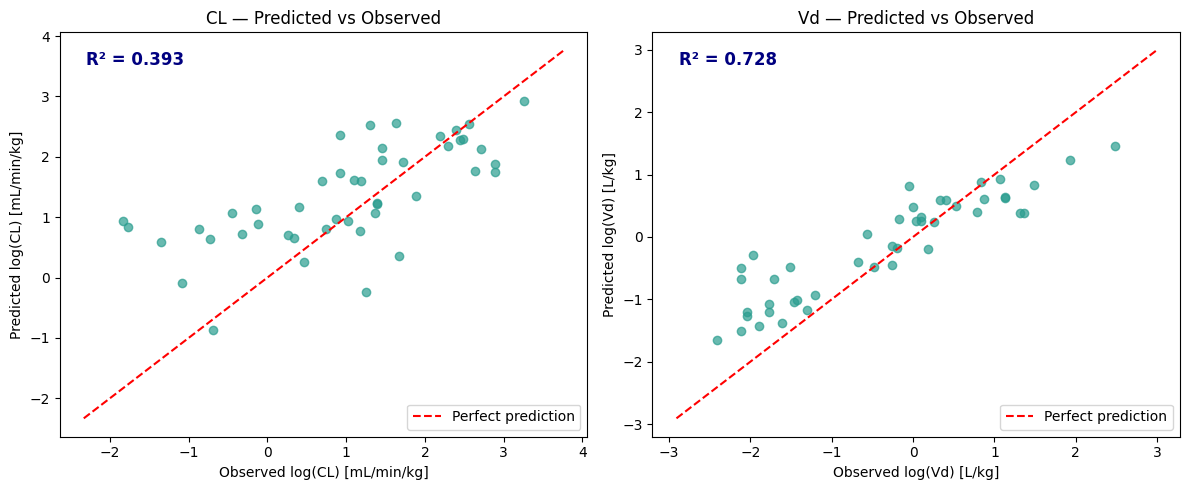

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, obs, pred, label, unit in [
    (axes[0], y_cl_eval, cl_preds, 'CL', 'mL/min/kg'),
    (axes[1], y_vd_eval, vd_preds, 'Vd', 'L/kg')
]:
    ax.scatter(obs, pred, alpha=0.7, color='#2a9d8f')
    lims = [min(obs.min(), pred.min()) - 0.5, max(obs.max(), pred.max()) + 0.5]
    ax.plot(lims, lims, 'r--', label='Perfect prediction')
    ax.set_xlabel(f'Observed log({label}) [{unit}]')
    ax.set_ylabel(f'Predicted log({label}) [{unit}]')
    ax.set_title(f'{label} — Predicted vs Observed')
    ax.text(0.05, 0.92, f'R² = {r2_score(obs, pred):.3f}',
            transform=ax.transAxes, fontsize=12, color='navy', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('CL_Vd_structure_only.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42, 'verbosity': 0, 'n_jobs': -1
    }
    model = XGBRegressor(**params)
    model.fit(X_cl_train, y_cl_train)
    preds = model.predict(X_cl_eval)
    return 10 ** np.mean(np.abs(np.log10(np.exp(preds) / np.exp(y_cl_eval))))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=300, show_progress_bar=True)

print(f"Best GMFE: {study.best_value:.3f}")
print(f"Best params: {study.best_params}")

# Retrain on best params
best_cl_model = XGBRegressor(**study.best_params, random_state=42, verbosity=0, n_jobs=-1)
best_cl_model.fit(X_cl_train, y_cl_train)

cl_preds = best_cl_model.predict(X_cl_eval)
r2_cl   = r2_score(y_cl_eval, cl_preds)
gmfe_cl = 10 ** np.mean(np.abs(np.log10(np.exp(cl_preds) / np.exp(y_cl_eval))))
print(f"\nTuned CL — Iwata eval:  R²={r2_cl:.3f}  GMFE={gmfe_cl:.2f}")

# External validation
preds_ext = best_cl_model.predict(X_chembl)
r2_ext   = r2_score(y_chembl, preds_ext)
gmfe_ext = 10 ** np.mean(np.abs(np.log10(np.exp(preds_ext) / np.exp(y_chembl))))
print(f"Tuned CL — ChEMBL ext:  R²={r2_ext:.3f}  GMFE={gmfe_ext:.2f}")

/opt/miniconda3/envs/pkip-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 19. Best value: 2.01208:   8%|▊         | 25/300 [12:53<2:21:46, 30.93s/it]


[W 2026-06-04 17:44:19,459] Trial 25 failed with parameters: {'n_estimators': 804, 'learning_rate': 0.03808282887004144, 'max_depth': 8, 'subsample': 0.8038471487814071, 'colsample_bytree': 0.7443804840764281, 'min_child_weight': 8, 'gamma': 0.6376933258475057, 'reg_alpha': 0.0024082961917718825, 'reg_lambda': 0.0588300748277249} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/opt/miniconda3/envs/pkip-env/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/v2/mst10l9d2736xhq9g2nkpynw0000gn/T/ipykernel_12160/479424812.py", line 18, in objective
    model.fit(X_cl_train, y_cl_train)
  File "/opt/miniconda3/envs/pkip-env/lib/python3.11/site-packages/xgboost/core.py", line 620, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/opt/miniconda3/envs/pkip-env/lib/python3.11/site-packages/xgboost/sklearn.py",

KeyboardInterrupt: 

[17:51:21] SMILES Parse Error: syntax error while parsing: nan
[17:51:21] SMILES Parse Error: check for mistakes around position 2:
[17:51:21] nan
[17:51:21] ~^
[17:51:21] SMILES Parse Error: Failed parsing SMILES 'nan' for input: 'nan'
[17:51:21] DEPRECATION WARNING: please use MorganGenerator
[17:51:21] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenera

CL — train: 749, test: 46
Vd — train: 760, test: 45


[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerator
[17:51:22] DEPRECATION WARNING: please use MorganGenerat

Feature dims: 2244
CL train: 748, Vd train: 759

CL (XGBoost) — Iwata test:  R²=0.387  GMFE=2.09
Vd (RF)      — Iwata test:  R²=0.734  GMFE=1.67


[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] DEPRECATION WARNING: please use MorganGenerator
[17:51:41] SMILES Parse Error: syntax error while parsing: nan
[17:51:41] SMILES Parse Error: check for mistakes around position 2:
[17:51:41] nan
[17:51:41] ~^
[17:51:41] SM

CL (XGBoost) — ChEMBL ext: R²=0.583  GMFE=1.82


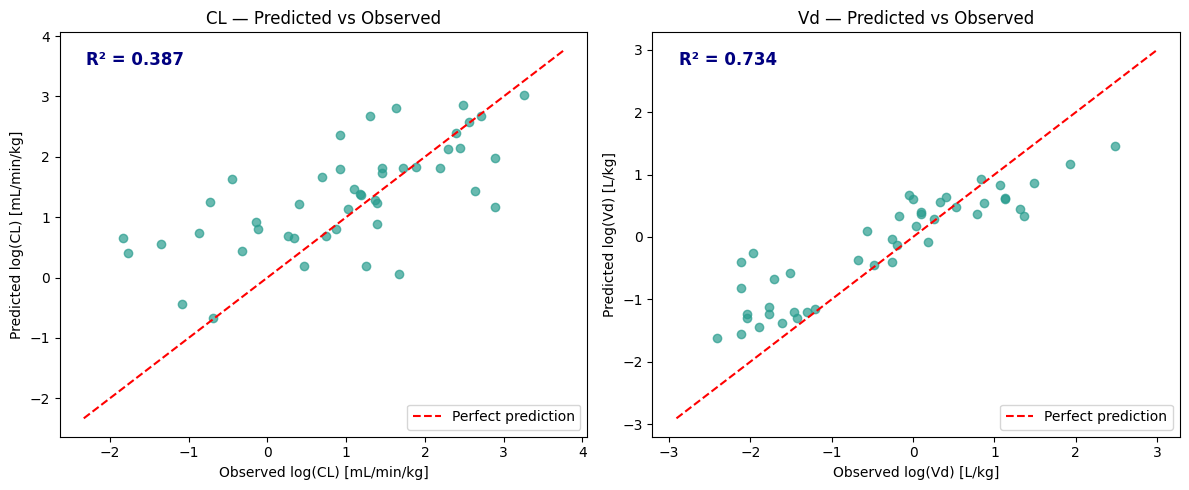

In [12]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys
from rdkit.Chem import MolToSmiles, MolFromSmiles
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# ── Descriptors — Ipc removed (overflows float32) ────────────────────────────
RDKIT_DESCRIPTORS = [
    ('MolWt',               Descriptors.MolWt),
    ('HeavyAtomCount',      Descriptors.HeavyAtomCount),
    ('NumValenceElectrons', Descriptors.NumValenceElectrons),
    ('MolLogP',             Descriptors.MolLogP),
    ('MolMR',               Descriptors.MolMR),
    ('TPSA',                Descriptors.TPSA),
    ('LabuteASA',           Descriptors.LabuteASA),
    ('NumHDonors',          Descriptors.NumHDonors),
    ('NumHAcceptors',       Descriptors.NumHAcceptors),
    ('NumRotatableBonds',   Descriptors.NumRotatableBonds),
    ('FractionCSP3',        Descriptors.FractionCSP3),
    ('BertzCT',             Descriptors.BertzCT),
    ('RingCount',           Descriptors.RingCount),
    ('NumAromaticRings',    Descriptors.NumAromaticRings),
    ('NumAliphaticRings',   Descriptors.NumAliphaticRings),
    ('NumSaturatedRings',   Descriptors.NumSaturatedRings),
    ('Kappa1',              Descriptors.Kappa1),
    ('Kappa2',              Descriptors.Kappa2),
    ('Kappa3',              Descriptors.Kappa3),
    ('Chi0v',               Descriptors.Chi0v),
    ('Chi1v',               Descriptors.Chi1v),
    ('Chi2v',               Descriptors.Chi2v),
    ('Chi3v',               Descriptors.Chi3v),
    ('MaxAbsEStateIndex',   Descriptors.MaxAbsEStateIndex),
    ('MinAbsEStateIndex',   Descriptors.MinAbsEStateIndex),
    ('PEOE_VSA1',           Descriptors.PEOE_VSA1),
    ('PEOE_VSA2',           Descriptors.PEOE_VSA2),
    ('SlogP_VSA1',          Descriptors.SlogP_VSA1),
    ('SMR_VSA1',            Descriptors.SMR_VSA1),
]

def compute_rdkit_descriptors(mol):
    vals = []
    for _, fn in RDKIT_DESCRIPTORS:
        try:
            v = float(fn(mol))
            vals.append(0.0 if (np.isnan(v) or np.isinf(v)) else v)
        except:
            vals.append(0.0)
    return np.array(vals)

def smiles_to_features(df, smiles_col='mol', radius=2, nbits=2048):
    fps_morgan, fps_maccs, descriptors, valid_idx = [], [], [], []
    for i, row in df.iterrows():
        mol = Chem.MolFromSmiles(str(row[smiles_col]))
        if mol is None:
            continue
        morgan = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits))
        maccs  = np.array(MACCSkeys.GenMACCSKeys(mol))
        rdkit  = compute_rdkit_descriptors(mol)
        fps_morgan.append(morgan)
        fps_maccs.append(maccs)
        descriptors.append(rdkit)
        valid_idx.append(i)
    X = np.hstack([np.array(fps_morgan), np.array(fps_maccs), np.array(descriptors)])
    X = np.clip(X, -1e9, 1e9)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, valid_idx

def canon(smi):
    try:
        mol = MolFromSmiles(str(smi))
        return MolToSmiles(mol) if mol else None
    except:
        return None

# ── File paths ────────────────────────────────────────────────────────────────
BASE      = r"/Users/francisbateman/Desktop/Wadhams Start Up/Code/"
ORIG_PATH = BASE + "CL_VD_Data.xlsx"
EXP_PATH  = BASE + "PKIP_expanded_dataset_FHB_06042026.xlsx"
CHEM_PATH = BASE + "ChEMBL_new_CL_compounds.xlsx"

# ── Load test sets ────────────────────────────────────────────────────────────
cl_eval = pd.read_excel(ORIG_PATH, sheet_name='CL_evaluation_dataset')
vd_eval = pd.read_excel(ORIG_PATH, sheet_name='VDss_evaluation_dataset')

eval_cl_smiles = set(cl_eval['mol'].apply(canon).dropna())
eval_vd_smiles = set(vd_eval['mol'].apply(canon).dropna())

# ── Load expanded training data ───────────────────────────────────────────────
all_data = pd.read_excel(EXP_PATH, sheet_name='All_Compounds')
all_data['canon'] = all_data['mol'].apply(canon)

cl_train = all_data[
    all_data['human_CL_mL_min_kg'].notna() &
    ~all_data['canon'].isin(eval_cl_smiles)
].copy()

vd_train = all_data[
    all_data['human_VDss_L_kg'].notna() &
    ~all_data['canon'].isin(eval_vd_smiles)
].copy()

print(f"CL — train: {len(cl_train)}, test: {len(cl_eval)}")
print(f"Vd — train: {len(vd_train)}, test: {len(vd_eval)}")

# ── Build feature matrices ────────────────────────────────────────────────────
X_cl_train, idx_cl_train = smiles_to_features(cl_train)
X_cl_eval,  idx_cl_eval  = smiles_to_features(cl_eval)
X_vd_train, idx_vd_train = smiles_to_features(vd_train)
X_vd_eval,  idx_vd_eval  = smiles_to_features(vd_eval)

y_cl_train = np.log(cl_train.loc[idx_cl_train, 'human_CL_mL_min_kg'].values)
y_cl_eval  = np.log(cl_eval.loc[idx_cl_eval,   'human_CL_mL_min_kg'].values)
y_vd_train = np.log(vd_train.loc[idx_vd_train, 'human_VDss_L_kg'].values)
y_vd_eval  = np.log(vd_eval.loc[idx_vd_eval,   'human_VDss_L_kg'].values)

# Clean targets
cl_mask = np.isfinite(y_cl_train)
X_cl_train, y_cl_train = X_cl_train[cl_mask], y_cl_train[cl_mask]
vd_mask = np.isfinite(y_vd_train)
X_vd_train, y_vd_train = X_vd_train[vd_mask], y_vd_train[vd_mask]

print(f"Feature dims: {X_cl_train.shape[1]}")
print(f"CL train: {X_cl_train.shape[0]}, Vd train: {X_vd_train.shape[0]}")

# ── Train CL — XGBoost ────────────────────────────────────────────────────────
xgb_cl = XGBRegressor(
    n_estimators=482, learning_rate=0.0461, max_depth=5,
    subsample=0.553, colsample_bytree=0.709, min_child_weight=8,
    gamma=1.234, reg_alpha=0.000522, reg_lambda=1.139,
    tree_method='exact', random_state=42, verbosity=0, n_jobs=-1
)
xgb_cl.fit(X_cl_train, y_cl_train)
cl_preds = xgb_cl.predict(X_cl_eval)

cl_r2   = r2_score(y_cl_eval, cl_preds)
cl_gmfe = 10 ** np.mean(np.abs(np.log10(np.exp(cl_preds) / np.exp(y_cl_eval))))
print(f"\nCL (XGBoost) — Iwata test:  R²={cl_r2:.3f}  GMFE={cl_gmfe:.2f}")

# ── Train Vd — Random Forest ──────────────────────────────────────────────────
rf_vd = RandomForestRegressor(
    n_estimators=500, max_features='sqrt',
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf_vd.fit(X_vd_train, y_vd_train)
vd_preds = rf_vd.predict(X_vd_eval)

vd_r2   = r2_score(y_vd_eval, vd_preds)
vd_gmfe = 10 ** np.mean(np.abs(np.log10(np.exp(vd_preds) / np.exp(y_vd_eval))))
print(f"Vd (RF)      — Iwata test:  R²={vd_r2:.3f}  GMFE={vd_gmfe:.2f}")

# ── External validation — ChEMBL ──────────────────────────────────────────────
chembl = pd.read_excel(CHEM_PATH, sheet_name='New_CL_Compounds')
chembl = chembl.rename(columns={'SMILES': 'mol'})

X_chembl, idx_chembl = smiles_to_features(chembl)
y_chembl = np.log(chembl.loc[idx_chembl, 'human_CL_mL_min_kg'].values)

cl_preds_ext = xgb_cl.predict(X_chembl)
cl_r2_ext    = r2_score(y_chembl, cl_preds_ext)
cl_gmfe_ext  = 10 ** np.mean(np.abs(np.log10(np.exp(cl_preds_ext) / np.exp(y_chembl))))
print(f"CL (XGBoost) — ChEMBL ext: R²={cl_r2_ext:.3f}  GMFE={cl_gmfe_ext:.2f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, obs, pred, label, unit in [
    (axes[0], y_cl_eval, cl_preds, 'CL', 'mL/min/kg'),
    (axes[1], y_vd_eval, vd_preds, 'Vd', 'L/kg')
]:
    ax.scatter(obs, pred, alpha=0.7, color='#2a9d8f')
    lims = [min(obs.min(), pred.min()) - 0.5, max(obs.max(), pred.max()) + 0.5]
    ax.plot(lims, lims, 'r--', label='Perfect prediction')
    ax.set_xlabel(f'Observed log({label}) [{unit}]')
    ax.set_ylabel(f'Predicted log({label}) [{unit}]')
    ax.set_title(f'{label} — Predicted vs Observed')
    ax.text(0.05, 0.92, f'R² = {r2_score(obs, pred):.3f}',
            transform=ax.transAxes, fontsize=12, color='navy', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('CL_Vd_expanded_v3.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ============================================================
# CELL 1: DIAGNOSTICS — run this first before retraining
# ============================================================
import pandas as pd
import numpy as np

BASE      = r"/Users/francisbateman/Desktop/Wadhams Start Up/Code/"
ORIG_PATH = BASE + "CL_VD_Data.xlsx"
EXP_PATH  = BASE + "PKIP_expanded_dataset_FHB_06042026.xlsx"
CHEM_PATH = BASE + "ChEMBL_new_CL_compounds.xlsx"

# Load original Iwata dataset
orig = pd.read_excel(ORIG_PATH, engine='calamine')
print(f"Original dataset: {orig.shape}")
print(f"Original columns: {list(orig.columns)}")
print(f"CL non-null: {orig['human_CL_mL_min_kg'].notna().sum()}")
print(f"Vd non-null: {orig['human_VDss_L_kg'].notna().sum()}")

# Load expanded dataset
exp = pd.read_excel(EXP_PATH, sheet_name='All_Compounds', engine='calamine')
print(f"\nExpanded dataset (All_Compounds): {exp.shape}")
print(f"Expanded columns: {list(exp.columns)}")
print(f"CL non-null: {exp['human_CL_mL_min_kg'].notna().sum()}")
print(f"Vd non-null: {exp['human_VDss_L_kg'].notna().sum()}")
print(f"SMILES non-null: {exp['mol'].notna().sum()}")

# Check SMILES column name
print(f"\nSMILES column candidates: {[c for c in exp.columns if 'smiles' in c.lower() or 'mol' in c.lower() or 'smi' in c.lower()]}")

# Check CL range
print(f"\nCL range (expanded): {exp['human_CL_mL_min_kg'].min():.3f} – {exp['human_CL_mL_min_kg'].max():.3f}")
print(f"CL log10 range: {np.log10(exp['human_CL_mL_min_kg'].dropna().clip(0.001)).min():.2f} – {np.log10(exp['human_CL_mL_min_kg'].dropna().clip(0.001)).max():.2f}")

Original dataset: (770, 18)
Original columns: ['mol', 'NAME', 'human_CL_mL_min_kg', 'human_VDss_L_kg', 'human_fup', 'monkey_CL_mL_min_kg', 'monkey_VDss_L_kg', 'monkey_fup', 'dog_CL_mL_min_kg', 'dog_VDss_L_kg', 'dog_fup', 'rat_CL_mL_min_kg', 'rat_VDss_L_kg', 'rat_fup', 'pKa_Acid', 'pKa_base', 'water_solubility', 'Caco_2']
CL non-null: 741
Vd non-null: 751

Expanded dataset (All_Compounds): (824, 11)
Expanded columns: ['NAME', 'mol', 'human_CL_mL_min_kg', 'human_VDss_L_kg', 'human_fup', 'rat_CL_mL_min_kg', 'rat_VDss_L_kg', 'dog_CL_mL_min_kg', 'dog_VDss_L_kg', 'monkey_CL_mL_min_kg', 'monkey_VDss_L_kg']
CL non-null: 795
Vd non-null: 805
SMILES non-null: 823

SMILES column candidates: ['mol']

CL range (expanded): 0.000 – 1070.000
CL log10 range: -3.00 – 3.03


In [15]:
# ============================================================
# CELL 2: LOAD + FEATURIZE (run after diagnostics confirm column names)
# ============================================================
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

RDKIT_DESCRIPTORS = [
    ('MolWt', Descriptors.MolWt),
    ('HeavyAtomCount', Descriptors.HeavyAtomCount),
    ('NumValenceElectrons', Descriptors.NumValenceElectrons),
    ('MolLogP', Descriptors.MolLogP),
    ('MolMR', Descriptors.MolMR),
    ('TPSA', Descriptors.TPSA),
    ('LabuteASA', Descriptors.LabuteASA),
    ('NumHDonors', Descriptors.NumHDonors),
    ('NumHAcceptors', Descriptors.NumHAcceptors),
    ('NumRotatableBonds', Descriptors.NumRotatableBonds),
    ('FractionCSP3', Descriptors.FractionCSP3),
    ('BertzCT', Descriptors.BertzCT),
    ('RingCount', Descriptors.RingCount),
    ('NumAromaticRings', Descriptors.NumAromaticRings),
    ('NumAliphaticRings', Descriptors.NumAliphaticRings),
    ('NumSaturatedRings', Descriptors.NumSaturatedRings),
    ('Kappa1', Descriptors.Kappa1),
    ('Kappa2', Descriptors.Kappa2),
    ('Kappa3', Descriptors.Kappa3),
    ('Chi0v', Descriptors.Chi0v),
    ('Chi1v', Descriptors.Chi1v),
    ('Chi2v', Descriptors.Chi2v),
    ('Chi3v', Descriptors.Chi3v),
    ('MaxAbsEStateIndex', Descriptors.MaxAbsEStateIndex),
    ('MinAbsEStateIndex', Descriptors.MinAbsEStateIndex),
    ('PEOE_VSA1', Descriptors.PEOE_VSA1),
    ('PEOE_VSA2', Descriptors.PEOE_VSA2),
    ('SlogP_VSA1', Descriptors.SlogP_VSA1),
    ('SMR_VSA1', Descriptors.SMR_VSA1),
]

def compute_rdkit_descriptors(mol):
    vals = []
    for _, fn in RDKIT_DESCRIPTORS:
        try:
            v = float(fn(mol))
            vals.append(0.0 if (np.isnan(v) or np.isinf(v)) else v)
        except:
            vals.append(0.0)
    return np.array(vals)

def smiles_to_features(df, smiles_col='mol', radius=2, nbits=2048):
    fps_morgan, fps_maccs, descriptors, valid_idx = [], [], [], []
    for i, row in df.iterrows():
        mol = Chem.MolFromSmiles(str(row[smiles_col]))
        if mol is None:
            continue
        morgan = np.array(AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nbits))
        maccs  = np.array(MACCSkeys.GenMACCSKeys(mol))
        rdkit  = compute_rdkit_descriptors(mol)
        fps_morgan.append(morgan)
        fps_maccs.append(maccs)
        descriptors.append(rdkit)
        valid_idx.append(i)
    X = np.hstack([np.array(fps_morgan), np.array(fps_maccs), np.array(descriptors)])
    X = np.clip(X, -1e9, 1e9)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X.astype(np.float64), valid_idx

def gmfe(y_true, y_pred):
    return np.exp(np.mean(np.abs(np.log(y_pred / y_true))))

# ── DETERMINE SMILES COLUMN ─────────────────────────────────
# Change 'mol' below if diagnostics showed a different column name
SMILES_COL = 'mol'

# ── LOAD EXPANDED DATASET ───────────────────────────────────
exp = pd.read_excel(EXP_PATH, sheet_name='All_Compounds', engine='calamine')
print(f"Loaded {len(exp)} compounds")

# ── CL DATASET ──────────────────────────────────────────────
cl_data = exp.dropna(subset=[SMILES_COL, 'human_CL_mL_min_kg']).copy()
cl_data = cl_data[cl_data['human_CL_mL_min_kg'] > 0].reset_index(drop=True)
print(f"CL-valid compounds: {len(cl_data)}")

X_cl, cl_valid_idx = smiles_to_features(cl_data, smiles_col=SMILES_COL)
cl_data_valid = cl_data.iloc[cl_valid_idx].reset_index(drop=True)
y_cl = np.log10(cl_data_valid['human_CL_mL_min_kg'].values)
print(f"CL featurized: {X_cl.shape}, y range: {y_cl.min():.2f} – {y_cl.max():.2f}")

# ── Vd DATASET ──────────────────────────────────────────────
vd_data = exp.dropna(subset=[SMILES_COL, 'human_VDss_L_kg']).copy()
vd_data = vd_data[vd_data['human_VDss_L_kg'] > 0].reset_index(drop=True)
print(f"Vd-valid compounds: {len(vd_data)}")

X_vd, vd_valid_idx = smiles_to_features(vd_data, smiles_col=SMILES_COL)
vd_data_valid = vd_data.iloc[vd_valid_idx].reset_index(drop=True)
y_vd = np.log10(vd_data_valid['human_VDss_L_kg'].values)
print(f"Vd featurized: {X_vd.shape}")

Loaded 824 compounds
CL-valid compounds: 794


[17:58:57] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerator
[17:58:58] DEPRECATION WARNING: please use MorganGenerat

CL featurized: (794, 2244), y range: -3.34 – 3.03
Vd-valid compounds: 804


[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerator
[17:59:08] DEPRECATION WARNING: please use MorganGenerat

Vd featurized: (804, 2244)


[17:59:19] DEPRECATION WARNING: please use MorganGenerator
[17:59:19] DEPRECATION WARNING: please use MorganGenerator
[17:59:19] DEPRECATION WARNING: please use MorganGenerator
[17:59:19] DEPRECATION WARNING: please use MorganGenerator
[17:59:19] DEPRECATION WARNING: please use MorganGenerator
[17:59:19] DEPRECATION WARNING: please use MorganGenerator
[17:59:19] DEPRECATION WARNING: please use MorganGenerator
[17:59:19] DEPRECATION WARNING: please use MorganGenerator


In [16]:
# ============================================================
# CELL 3: TRAIN/TEST SPLIT + MODEL FIT
# ============================================================

# ── CL SPLIT ────────────────────────────────────────────────
X_cl_train, X_cl_test, y_cl_train, y_cl_test = train_test_split(
    X_cl, y_cl, test_size=0.10, random_state=42
)
print(f"CL train: {len(X_cl_train)}, test: {len(X_cl_test)}")

cl_params = dict(
    n_estimators=482, learning_rate=0.0461, max_depth=5,
    subsample=0.553, colsample_bytree=0.709, min_child_weight=8,
    gamma=1.234, reg_alpha=0.000522, reg_lambda=1.139,
    tree_method='exact',
    device='cpu',
    random_state=42,
    n_jobs=-1,
)

xgb_cl = xgb.XGBRegressor(**cl_params)
xgb_cl.fit(X_cl_train, y_cl_train,
            eval_set=[(X_cl_test, y_cl_test)],
            verbose=False)

cl_pred_log = xgb_cl.predict(X_cl_test)
cl_pred     = 10**cl_pred_log
cl_true     = 10**y_cl_test
cl_r2       = r2_score(y_cl_test, cl_pred_log)
cl_gmfe     = gmfe(cl_true, cl_pred)

print(f"\nCL — XGBoost")
print(f"  R²  (log scale): {cl_r2:.3f}")
print(f"  GMFE:            {cl_gmfe:.3f}")

# ── Vd SPLIT ────────────────────────────────────────────────
X_vd_train, X_vd_test, y_vd_train, y_vd_test = train_test_split(
    X_vd, y_vd, test_size=0.10, random_state=42
)
print(f"\nVd train: {len(X_vd_train)}, test: {len(X_vd_test)}")

rf_vd = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf_vd.fit(X_vd_train, y_vd_train)

vd_pred_log = rf_vd.predict(X_vd_test)
vd_pred     = 10**vd_pred_log
vd_true     = 10**y_vd_test
vd_r2       = r2_score(y_vd_test, vd_pred_log)
vd_gmfe     = gmfe(vd_true, vd_pred)

print(f"\nVd — Random Forest")
print(f"  R²  (log scale): {vd_r2:.3f}")
print(f"  GMFE:            {vd_gmfe:.3f}")

CL train: 714, test: 80
[18:00:43] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1700181009589/work/src/learner.cc:767: 
Parameters: { "device" } are not used.


CL — XGBoost
  R²  (log scale): 0.439
  GMFE:            2.288

Vd train: 723, test: 81

Vd — Random Forest
  R²  (log scale): 0.416
  GMFE:            2.050


In [17]:
# ============================================================
# DIAGNOSTIC: Check the 54 Lombardo additions' Vd values
# ============================================================

# Load the Lombardo-new sheet specifically
lombardo_new = pd.read_excel(EXP_PATH, sheet_name='Lombardo_New', engine='calamine')
print(f"Lombardo new compounds: {len(lombardo_new)}")
print(f"Vd non-null: {lombardo_new['human_VDss_L_kg'].notna().sum()}")
print(f"\nVd stats (Lombardo new):")
print(lombardo_new['human_VDss_L_kg'].describe())

# Compare against original 770
orig_vd = orig['human_VDss_L_kg'].dropna()
lomb_vd = lombardo_new['human_VDss_L_kg'].dropna()
print(f"\nOriginal 770 — Vd stats:")
print(orig_vd.describe())

print(f"\nLog10 Vd range (original): {np.log10(orig_vd.clip(0.001)).min():.2f} – {np.log10(orig_vd.clip(0.001)).max():.2f}")
print(f"Log10 Vd range (lombardo new): {np.log10(lomb_vd.clip(0.001)).min():.2f} – {np.log10(lomb_vd.clip(0.001)).max():.2f}")

# Print any extreme outliers in Lombardo Vd
outliers = lombardo_new[lombardo_new['human_VDss_L_kg'] > 20]
print(f"\nLombardo compounds with Vd > 20 L/kg: {len(outliers)}")
if len(outliers) > 0:
    print(outliers[['NAME', 'human_VDss_L_kg', 'human_CL_mL_min_kg']])

Lombardo new compounds: 54
Vd non-null: 54

Vd stats (Lombardo new):
count    54.000000
mean      1.471667
std       1.961309
min       0.050000
25%       0.260000
50%       0.925000
75%       1.775000
max      12.000000
Name: human_VDss_L_kg, dtype: float64

Original 770 — Vd stats:
count    751.000000
mean       4.008557
std       26.900648
min        0.035000
25%        0.300000
50%        0.950000
75%        2.500000
max      700.000000
Name: human_VDss_L_kg, dtype: float64

Log10 Vd range (original): -1.46 – 2.85
Log10 Vd range (lombardo new): -1.30 – 1.08

Lombardo compounds with Vd > 20 L/kg: 0


In [18]:
print(f"X_vd shape: {X_vd.shape}")
print(f"y_vd range: {y_vd.min():.3f} – {y_vd.max():.3f}")
print(f"y_vd mean: {y_vd.mean():.3f}")
print(f"X_vd any NaN: {np.isnan(X_vd).any()}")
print(f"X_vd any Inf: {np.isinf(X_vd).any()}")

X_vd shape: (804, 2244)
y_vd range: -1.456 – 2.845
y_vd mean: -0.014
X_vd any NaN: False
X_vd any Inf: False


In [19]:
# ============================================================
# CROSS-VALIDATION BASELINE (5-fold)
# ============================================================
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# CL — XGBoost
xgb_cv = xgb.XGBRegressor(**cl_params)
cl_cv_scores = cross_val_score(xgb_cv, X_cl, y_cl, cv=kf, scoring='r2', n_jobs=-1)
print(f"CL 5-fold R²: {cl_cv_scores.mean():.3f} ± {cl_cv_scores.std():.3f}")
print(f"  fold scores: {[f'{s:.3f}' for s in cl_cv_scores]}")

# CL GMFE per fold
cl_gmfes = []
for train_idx, test_idx in kf.split(X_cl):
    m = xgb.XGBRegressor(**cl_params)
    m.fit(X_cl[train_idx], y_cl[train_idx])
    pred = 10**m.predict(X_cl[test_idx])
    true = 10**y_cl[test_idx]
    cl_gmfes.append(gmfe(true, pred))
print(f"CL 5-fold GMFE: {np.mean(cl_gmfes):.3f} ± {np.std(cl_gmfes):.3f}")

# Vd — Random Forest
rf_cv = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
vd_cv_scores = cross_val_score(rf_cv, X_vd, y_vd, cv=kf, scoring='r2', n_jobs=-1)
print(f"\nVd 5-fold R²: {vd_cv_scores.mean():.3f} ± {vd_cv_scores.std():.3f}")
print(f"  fold scores: {[f'{s:.3f}' for s in vd_cv_scores]}")

# Vd GMFE per fold
vd_gmfes = []
for train_idx, test_idx in kf.split(X_vd):
    m = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
    m.fit(X_vd[train_idx], y_vd[train_idx])
    pred = 10**m.predict(X_vd[test_idx])
    true = 10**y_vd[test_idx]
    vd_gmfes.append(gmfe(true, pred))
print(f"Vd 5-fold GMFE: {np.mean(vd_gmfes):.3f} ± {np.std(vd_gmfes):.3f}")

[18:05:45] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1700181009589/work/src/learner.cc:767: 
Parameters: { "device" } are not used.

[18:05:45] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1700181009589/work/src/learner.cc:767: 
Parameters: { "device" } are not used.

[18:05:45] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1700181009589/work/src/learner.cc:767: 
Parameters: { "device" } are not used.

[18:05:45] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1700181009589/work/src/learner.cc:767: 
Parameters: { "device" } are not used.

[18:05:45] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1700181009589/work/src/learner.cc:767: 
Parameters: { "device" } are not used.

CL 5-fold R²: 0.343 ± 0.113
  fold scores: ['0.258', '0.525', '0.233', '0.425', '0.273']
[18:06:18] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1700181009589/work/src/learner.cc:767: 
Parameters: { "device" } are not used.

[18:06:24] WARNIN